# Evaluación Comparativa de Modelos
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** Responder PI1 — ¿qué familia de modelos ofrece el mejor equilibrio
entre rendimiento predictivo, estabilidad temporal e interpretabilidad?

Este notebook carga los modelos y resultados generados en `02_preprocesamiento_entrenamiento.ipynb`
y produce el análisis comparativo completo (OE2).

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y configuración |
| 3 | Tabla maestra de métricas |
| 4 | Visualización comparativa |
| 5 | Matrices de confusión |
| 6 | Análisis de rendimiento por subregión y país |
| 7 | Test estadístico (Friedman + Nemenyi) |
| 8 | Selección del modelo principal para XAI |
| 9 | Guardado de resultados de evaluación |

## 1. Importaciones

In [17]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, THEME, PATHS, SPLIT, SUBREGIONES,
    PAISES_EXCLUIR_EVAL, COL_TARGET, COL_PAIS, ETIQUETAS, N_CLASES,
    ETIQUETAS_FEATURES, BLOQUES,
)
from utils.io import (
    cargar_pipeline, cargar_resultados, cargar_split_parquet,
    listar_pipelines_disponibles, cargar_mejor_modelo,
)
from utils.plots import (
    plot_metricas_comparativas, plot_matrices_confusion,
    plot_rendimiento_por_pais, save_figure, model_color,
)
from utils.metrics import evaluar

setup_plots()
print("✓ Importaciones completadas.")

✓ Importaciones completadas.


## 2. Configuración

In [18]:
# =============================================================================
# Parámetros del notebook de evaluación
# =============================================================================

# ── Bandera: matrices de confusión ────────────────────────────────────────────
# True  → una matriz por cada combinación modelo × estrategia (15 matrices)
# False → solo el mejor modelo por conjunto (3 matrices)
CONFUSION_TODOS_MODELOS = True

# ── Bandera: test estadístico ─────────────────────────────────────────────────
# Incluir test de Friedman + post-hoc de Nemenyi entre modelos.
# Con n=1 split único la potencia es baja, pero se documenta para rigor.
EJECUTAR_TEST_ESTADISTICO = True

# ── Métrica principal de comparación ─────────────────────────────────────────
METRICA_PRINCIPAL = "kappa_cuadratico"

# ── Modelos a evaluar ─────────────────────────────────────────────────────────
MODELOS = ["OLO", "XGBoost", "CatBoost", "LightGBM", "TabNet"]

print("Pipelines disponibles:")
print(listar_pipelines_disponibles().to_string(index=False))

Pipelines disponibles:
               modelo                                         ruta  tamaño_kb
 CatBoost_pesos_clase  ../models/pipeline_CatBoost_pesos_clase.pkl      643.4
CatBoost_sin_balanceo ../models/pipeline_CatBoost_sin_balanceo.pkl      907.9
     CatBoost_smotenc      ../models/pipeline_CatBoost_smotenc.pkl      248.9
 LightGBM_pesos_clase  ../models/pipeline_LightGBM_pesos_clase.pkl    14782.1
LightGBM_sin_balanceo ../models/pipeline_LightGBM_sin_balanceo.pkl     4472.8
     LightGBM_smotenc      ../models/pipeline_LightGBM_smotenc.pkl      410.8
      OLO_pesos_clase       ../models/pipeline_OLO_pesos_clase.pkl     1785.3
     OLO_sin_balanceo      ../models/pipeline_OLO_sin_balanceo.pkl     1785.4
          OLO_smotenc           ../models/pipeline_OLO_smotenc.pkl      190.7
   TabNet_pesos_clase    ../models/pipeline_TabNet_pesos_clase.pkl     6394.5
  TabNet_sin_balanceo   ../models/pipeline_TabNet_sin_balanceo.pkl     6394.3
       TabNet_smotenc        ../models/pi

## 3. Tabla maestra de métricas

Carga los resultados del conjunto de **prueba** del split único.
Cada split tiene su propio conjunto de validación (usado solo en Optuna)
y conjunto de prueba (reportado aquí).

| split | Train | Validación | Prueba |
|---|---|---|---|
| Test | 1995–2005 | 2006 | 2007 |
| Test | 1995–2016 | 2017 | 2018 |
| Test | 2023, 2024 | — | — |  # conjunto de prueba del split único

In [19]:
# =============================================================================
# Cargar resultados del conjunto de prueba
# =============================================================================
df_test = cargar_resultados(split="test")
df_val  = cargar_resultados(split="val")

print("Métricas en conjunto de PRUEBA:")
cols = ["modelo", "estrategia_balanceo", "balanced_accuracy", "f1_macro",
        "kappa_lineal", "kappa_cuadratico", "mae_ordinal", "auroc_macro"]
print(df_test[[c for c in cols if c in df_test.columns]]
      .sort_values(["estrategia_balanceo", METRICA_PRINCIPAL], ascending=[True, False])
      .to_string(index=False, float_format="{:.4f}".format))

print("\nKappa Cuadrático — pivot (modelo × estrategia):")
pivot = df_test.pivot(index="modelo", columns="estrategia_balanceo",
                      values="kappa_cuadratico")
print(pivot.to_string(float_format="{:.4f}".format))

# Guardar tabla
pivot.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_kappa_pivot.csv")
df_test.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_completas_test.csv",
               index=False)
print("\n✓ Tablas guardadas en results/tables/")


Métricas en conjunto de PRUEBA:
  modelo estrategia_balanceo  balanced_accuracy  f1_macro  kappa_lineal  kappa_cuadratico  mae_ordinal  auroc_macro
 XGBoost         pesos_clase             0.4845    0.4896        0.4154            0.5250       0.5725       0.7714
     OLO         pesos_clase             0.4893    0.4266        0.3946            0.5189       0.7313       0.7529
CatBoost         pesos_clase             0.5278    0.5010        0.4311            0.5121       0.6260       0.7779
  TabNet         pesos_clase             0.4615    0.4416        0.3723            0.5006       0.6794       0.7281
LightGBM         pesos_clase             0.4804    0.4527        0.3855            0.4952       0.6748       0.7309
CatBoost        sin_balanceo             0.4658    0.4879        0.4171            0.5385       0.5130       0.7846
 XGBoost        sin_balanceo             0.4674    0.4916        0.3999            0.5125       0.5282       0.7771
LightGBM        sin_balanceo            

## 4. Visualización comparativa

  ✓ Figura guardada: 03_metricas_comparativas.png


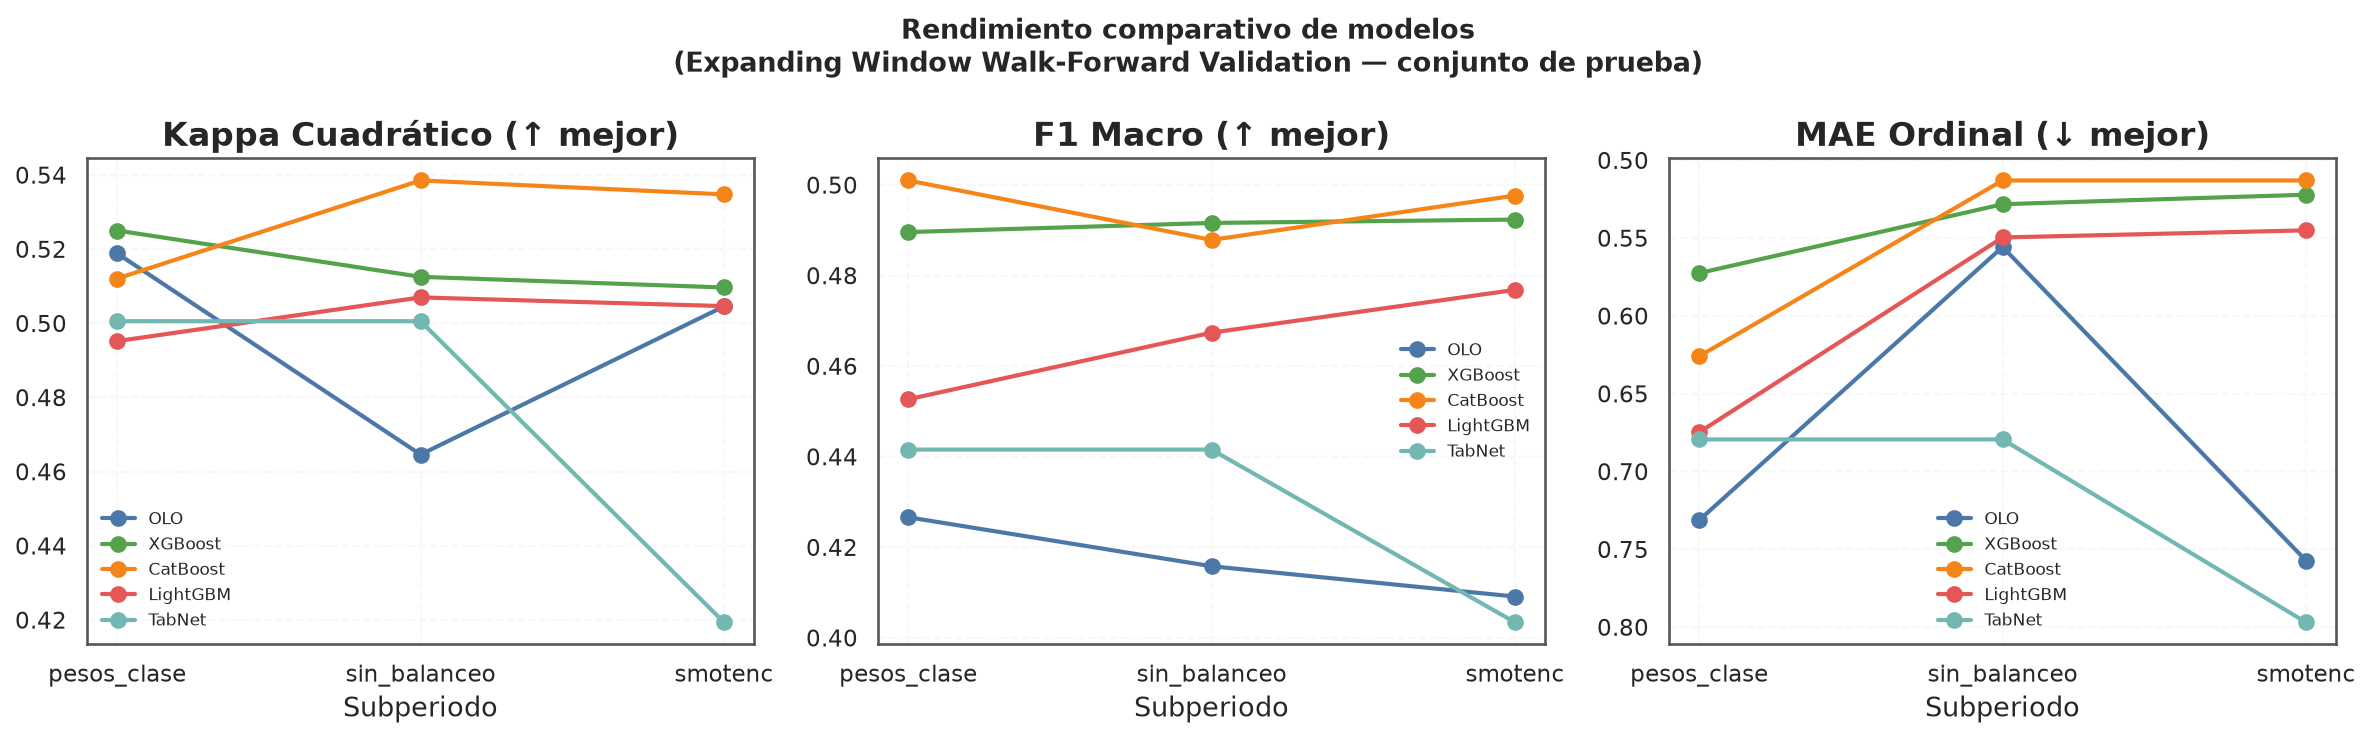

In [20]:
# =============================================================================
# Gráficos de rendimiento por modelo y split
# =============================================================================
plot_metricas_comparativas(df_test, nombre_archivo="03_metricas_comparativas")

  ✓ Figura guardada: 03_val_vs_test.png


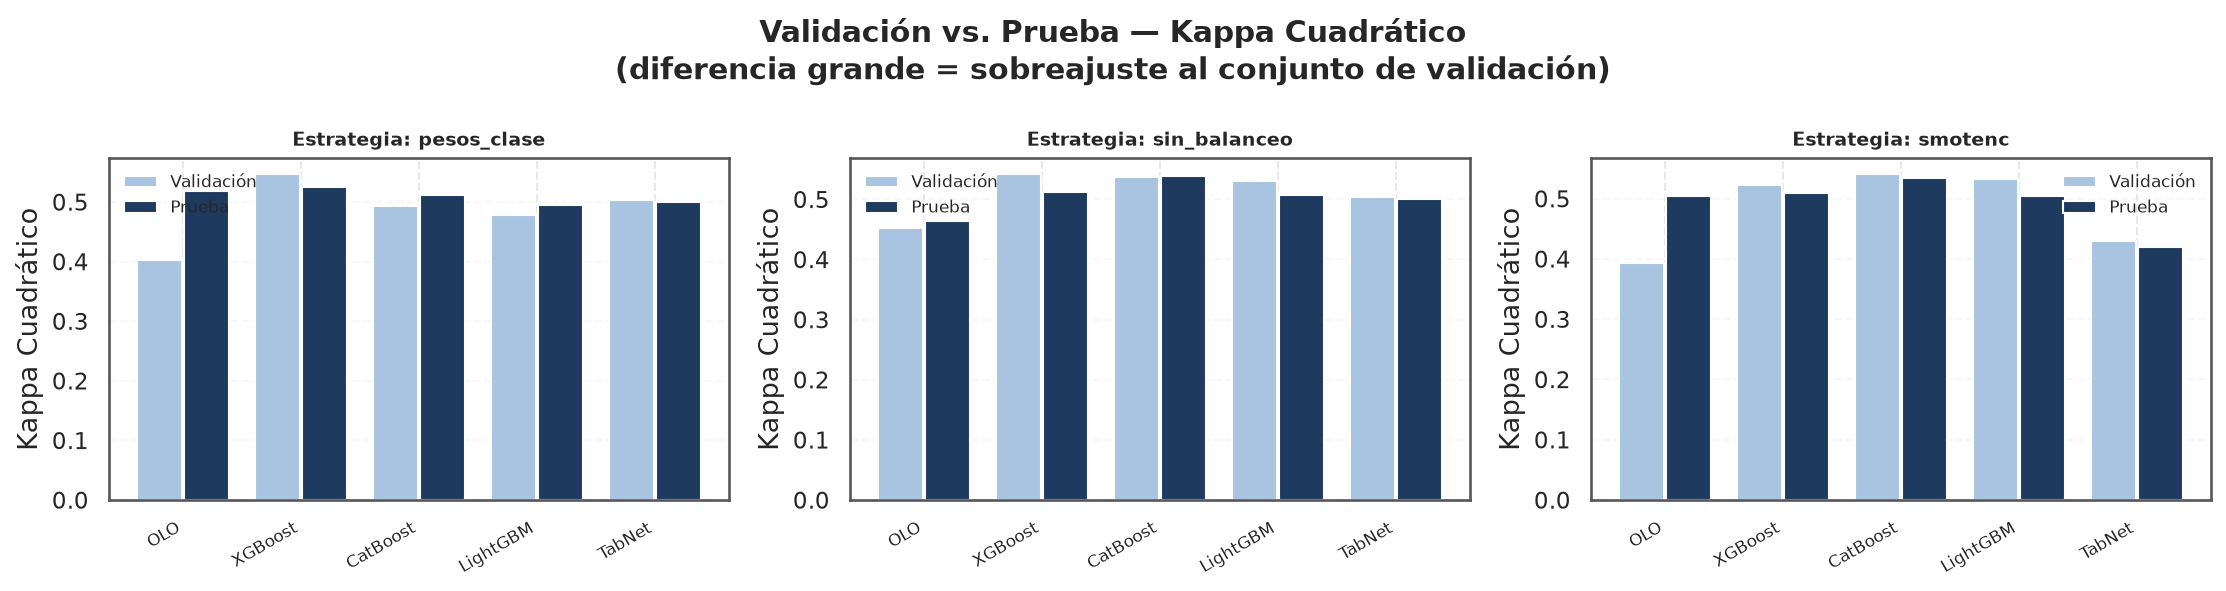

In [21]:
# =============================================================================
# Comparación validación vs. prueba para detectar sobreajuste
# =============================================================================
estrategias = sorted(df_test["estrategia_balanceo"].unique())
fig, axes = plt.subplots(1, len(estrategias), figsize=(5 * len(estrategias), 4))
if len(estrategias) == 1:
    axes = [axes]
fig.suptitle("Validación vs. Prueba — Kappa Cuadrático\n"
             "(diferencia grande = sobreajuste al conjunto de validación)",
             fontweight="bold")

for ax, estrat in zip(axes, estrategias):
    sub_val  = df_val[df_val["estrategia_balanceo"] == estrat].set_index("modelo")["kappa_cuadratico"]
    sub_test = df_test[df_test["estrategia_balanceo"] == estrat].set_index("modelo")["kappa_cuadratico"]

    modelos_comunes = [m for m in MODELOS if m in sub_val.index and m in sub_test.index]
    x = np.arange(len(modelos_comunes))

    ax.bar(x - 0.2, [sub_val[m] for m in modelos_comunes], 0.38,
           label="Validación", color="#A8C4E0", edgecolor="white")
    ax.bar(x + 0.2, [sub_test[m] for m in modelos_comunes], 0.38,
           label="Prueba", color="#1E3A5F", edgecolor="white")
    ax.set_title(f"Estrategia: {estrat}", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos_comunes, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Kappa Cuadrático")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

save_figure("03_val_vs_test")
plt.show()


## 5. Matrices de confusión

In [22]:
# =============================================================================
# Reconstruir predicciones para las matrices de confusión
# =============================================================================
# Se cargan los pipelines y se regeneran predicciones sobre el test set.
# El parámetro CONFUSION_TODOS_MODELOS controla si se muestran todos
# los modelos o solo el mejor por conjunto.
# =============================================================================

import joblib

resultados_cm: Dict = {}   # clave: (modelo, sp) → (y_true, y_pred)

for sp in ["test","test","test"]:
    df_te = cargar_split_parquet(sp, "test")
    y_te  = df_te[COL_TARGET].astype(int).values

    for modelo in MODELOS:
        try:
            art = cargar_pipeline(modelo, sp)
            tipo = art["tipo_modelo"]
            feats = art["features"]
            X_te  = df_te[[f for f in feats if f in df_te.columns]]
            X_te  = X_te.reindex(columns=feats)

            if tipo in ("olo", "tabnet"):
                # Separar S_200 de las numéricas porque imp_num se ajustó sin ella
                vars_cat = [c for c in art.get("vars_categoricas", []) if c in X_te.columns]
                cols_num = [c for c in feats if c not in vars_cat]

                X_num = pd.DataFrame(
                    art["imp_num"].transform(X_te[cols_num]),
                    columns=cols_num, index=X_te.index)

                if vars_cat and art.get("imp_cat") is not None:
                    X_cat = pd.DataFrame(
                        art["imp_cat"].transform(X_te[vars_cat]),
                        columns=vars_cat, index=X_te.index)
                    X_imp = pd.concat([X_num, X_cat], axis=1)[feats]
                else:
                    X_imp = X_num

                cols_num_sc = [c for c in feats if c not in vars_cat]
                X_sc = X_imp.copy()
                X_sc[cols_num_sc] = art["scaler"].transform(X_imp[cols_num_sc])

                if tipo == "olo":
                    y_pred = art["modelo"].predict(X_sc.values)
                else:
                    y_pred = art["modelo"].predict(X_sc.values.astype(np.float32))

            else:  # trees
                X_in = X_te.copy()
                if modelo == "CatBoost":
                    for col in art.get("vars_categoricas", []):
                        if col in X_in.columns:
                            X_in[col] = X_in[col].fillna(-999).astype(int).astype(str)
                elif modelo == "LightGBM":
                    # LightGBM necesita el mismo CategoricalDtype que se usó en el fit
                    # Se reconstruye con los valores únicos de la columna en este conjunto
                    for col in art.get("vars_categoricas", []):
                        if col in X_in.columns:
                            cats = sorted(X_in[col].dropna().unique().tolist())
                            ct = pd.CategoricalDtype(categories=cats, ordered=False)
                            X_in[col] = X_in[col].astype(ct)
                y_raw  = art["modelo"].predict(X_in)
                y_pred = y_raw.flatten() if hasattr(y_raw, "flatten") else y_raw

            resultados_cm[(modelo, sp)] = (y_te, y_pred)
        except FileNotFoundError:
            print(f"  ⚠ Pipeline no encontrado: {modelo} — {sp}")
        except Exception as e:
            print(f"  ⚠ Error en {modelo} — {sp}: {e}")

print(f"✓ Predicciones reconstruidas para {len(resultados_cm)} combinaciones")

TypeError: cargar_split_parquet() takes from 0 to 1 positional arguments but 2 were given

In [ ]:
# Mejor modelo por conjunto
mejor_por_sp = {}
for sp in ["test","test","test"]:
    try:
        mejor_por_sp[sp] = cargar_mejor_modelo(sp, METRICA_PRINCIPAL)
        print(f"  Mejor modelo {sp}: {mejor_por_sp[sp]}")
    except Exception as e:
        print(f"  ⚠ {sp}: {e}")

# Generar matrices
mejor_global = cargar_mejor_modelo("test", METRICA_PRINCIPAL)

plot_matrices_confusion(
    resultados_cm,
    solo_mejor     = not CONFUSION_TODOS_MODELOS,
    mejor_modelo   = mejor_global,
    nombre_archivo = "03_matrices_confusion",
)

## 6. Análisis de rendimiento por subregión y país

In [ ]:
# =============================================================================
# MAE ordinal por país en el conjunto de prueba (Test)
# Venezuela y Nicaragua excluidos del análisis por país (ver metodología).
# =============================================================================
from sklearn.metrics import mean_absolute_error

filas_pais = []
sp_eval    = "Test"   # análisis principal sobre el split más reciente

df_te_full = cargar_split_parquet(sp_eval, "test")

# Añadir columna de país si está disponible
if COL_PAIS not in df_te_full.columns:
    print("⚠ Columna pais_nombre no disponible en el Parquet de test.")
    print("  Para el análisis por país se necesita el DataFrame completo.")
else:
    y_te_full = df_te_full[COL_TARGET].astype(int).values
    paises_test = df_te_full[COL_PAIS].unique()
    paises_analizar = [p for p in paises_test if p not in PAISES_EXCLUIR_EVAL]

    for modelo in MODELOS:
        if (modelo, sp_eval) not in resultados_cm:
            continue
        y_pred_full = resultados_cm[(modelo, sp_eval)][1]

        for pais in paises_analizar:
            mask = df_te_full[COL_PAIS] == pais
            if mask.sum() < 10:
                continue
            mae = mean_absolute_error(y_te_full[mask], y_pred_full[mask])
            # Identificar subregión
            subregion = "Sin clasificar"
            for sr, paises_sr in SUBREGIONES.items():
                if pais in paises_sr:
                    subregion = sr
                    break
            filas_pais.append({
                "modelo": modelo, "split": sp_eval,
                "pais": pais, "subregion": subregion,
                "mae_ordinal": mae, "n": int(mask.sum()),
            })

    df_mae_pais = pd.DataFrame(filas_pais)
    if not df_mae_pais.empty:
        print(f"Análisis por país — {sp_eval}:")
        print(df_mae_pais.groupby(["subregion","modelo"])["mae_ordinal"]
              .mean().unstack().round(3).to_string())
        df_mae_pais.to_csv(
            PATHS["FOLDER_RESULTS_TABLES"] / f"mae_por_pais_{sp_eval}.csv",
            index=False)
        print("\n✓ Tabla guardada")
    else:
        print("⚠ Sin datos por país — verificar Parquet de test.")

In [ ]:
# Gráfico MAE por país
if 'df_mae_pais' in dir() and not df_mae_pais.empty:
    plot_rendimiento_por_pais(df_mae_pais, split=sp_eval,
                              nombre_archivo="03_mae_por_pais")

# Heatmap: MAE por subregión × split para el mejor modelo
if 'df_mae_pais' in dir() and not df_mae_pais.empty:
    mejor_m = cargar_mejor_modelo("Test", METRICA_PRINCIPAL)
    df_sr   = (df_mae_pais[df_mae_pais["modelo"] == mejor_m]
               .groupby(["subregion","split"])["mae_ordinal"].mean()
               .unstack())

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(df_sr, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.3, ax=ax, cbar_kws={"label": "MAE Ordinal"})
    ax.set_title(f"MAE Ordinal por subregión — {mejor_m}",
                 fontweight="bold")
    save_figure("03_mae_subregion_heatmap")
    plt.show()

## 7. Test estadístico de diferencias entre modelos

**Test de Friedman** (Demšar, 2006): evalúa si las diferencias de rendimiento
entre modelos son estadísticamente significativas considerando todos los
splits como bloques.

**Nota metodológica:** con n=3 splits la potencia estadística es baja.
Los resultados se interpretan como evidencia indicativa, no concluyente.

In [ ]:
if EJECUTAR_TEST_ESTADISTICO:
    from scipy.stats import friedmanchisquare

    # Construir matriz: modelos × splits (solo test)
    sps_ord = ["Test","Test","Test"]
    matriz  = []
    for modelo in MODELOS:
        fila = []
        for sp in sps_ord:
            sub = df_test[(df_test["modelo"]==modelo) & (df_test["split"]==sp)]
            fila.append(sub[METRICA_PRINCIPAL].values[0] if len(sub) > 0 else np.nan)
        matriz.append(fila)
    mat = np.array(matriz)   # shape: (5 modelos × 3 splits)

    # Test de Friedman (k=modelos como tratamientos, n=splits como bloques)
    stat, p_val = friedmanchisquare(*mat.T)   # transponer: filas=bloques
    print(f"Test de Friedman")
    print(f"  Estadístico χ²F = {stat:.4f}")
    print(f"  p-valor          = {p_val:.4f}")
    print(f"  Conclusión       : {'Diferencias significativas (α=0.05)' if p_val < 0.05 else 'Sin evidencia de diferencias significativas (α=0.05)'}")
    print(f"\n  ⚠ Nota: n=3 bloques implica baja potencia estadística.")
    print(f"         Los resultados son indicativos.")

    # Post-hoc de Nemenyi si Friedman es significativo
    if p_val < 0.05:
        try:
            from scikit_posthocs import posthoc_nemenyi_friedman
            df_nemenyi = posthoc_nemenyi_friedman(mat.T)
            df_nemenyi.index   = MODELOS
            df_nemenyi.columns = MODELOS
            print("\nPost-hoc Nemenyi (p-valores):")
            print(df_nemenyi.round(4).to_string())
            df_nemenyi.to_csv(
                PATHS["FOLDER_RESULTS_TABLES"] / "nemenyi_pvalues.csv")
        except ImportError:
            print("\n  ⚠ scikit-posthocs no instalado.")
            print("     Instalar con: pip install scikit-posthocs")
else:
    print("Test estadístico desactivado (EJECUTAR_TEST_ESTADISTICO = False)")

## 8. Selección del modelo principal para análisis XAI

In [ ]:
# =============================================================================
# El modelo con mejor Kappa Cuadrático en Test (conjunto de prueba) se define
# como modelo principal para el análisis de explicabilidad (notebook 04).
# Esta selección puede sobreescribirse manualmente en el notebook 04.
# =============================================================================

mejor_modelo_xai = cargar_mejor_modelo("Test", METRICA_PRINCIPAL)

print(f"Modelo principal para análisis XAI: {mejor_modelo_xai}")
print(f"Criterio: mayor {METRICA_PRINCIPAL} en Test (conjunto de prueba)")
print()
print("Ranking completo Test:")
sub_sp3 = (df_test[df_test["split"]=="Test"]
           .sort_values(METRICA_PRINCIPAL, ascending=False))
for _, row in sub_sp3.iterrows():
    marca = " ← SELECCIONADO" if row["modelo"] == mejor_modelo_xai else ""
    print(f"  {row['modelo']:<12}: {METRICA_PRINCIPAL}={row[METRICA_PRINCIPAL]:.4f}{marca}")

# Guardar selección para uso en notebooks 04–06
seleccion = {"modelo_xai": mejor_modelo_xai, "metrica": METRICA_PRINCIPAL,
             "split_referencia": "Test"}
import json
ruta_sel = PATHS["FOLDER_RESULTS"] / "modelo_xai_seleccionado.json"
ruta_sel.write_text(json.dumps(seleccion, indent=2))
print(f"\n✓ Selección guardada: {ruta_sel}")

## 9. Resumen y guardado

In [ ]:
# =============================================================================
# Resumen ejecutivo del notebook 03
# =============================================================================
print("=" * 60)
print("RESUMEN — Evaluación comparativa de modelos")
print("=" * 60)
print(f"  Subperiodos evaluados : Test, Test, Test")
print(f"  Modelos evaluados     : {', '.join(MODELOS)}")
print(f"  Métrica principal     : {METRICA_PRINCIPAL}")
print()
print("Mejor modelo por split (Kappa Cuadrático):")
for sp in ["Test","Test","Test"]:
    try:
        m = cargar_mejor_modelo(sp, METRICA_PRINCIPAL)
        val = df_test[(df_test["modelo"]==m) & (df_test["split"]==sp)][METRICA_PRINCIPAL].values[0]
        print(f"  {sp}: {m} ({val:.4f})")
    except:
        print(f"  {sp}: sin datos")
print()
print("Archivos generados en results/:")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*.csv")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("03_*.png")):
    print(f"  {f.name}")